# Importe des Variables

In [1]:
import pickle
from pathlib import Path

data_dir = Path("Data")
data_dir.mkdir(exist_ok=True)
with open(data_dir / "ffor_data.pkl", "rb") as f_pkl:
    d = pickle.load(f_pkl)

# Remettre toutes les variables dans le namespace local
locals().update(d)

scenario_file = data_dir / "ffor_grid_scenarios.pkl"
if not scenario_file.exists():
    raise FileNotFoundError(f"Impossible de trouver {scenario_file}. Execute d'abord grid_generation_belalp.ipynb.")
with open(scenario_file, "rb") as f_pkl:
    scenarios = pickle.load(f_pkl)

# FFOR temporel local: reseau MV sans Belalp. Pour tester l'autre topologie,
# utiliser "with_belalp"; la disponibilite Belalp reste alors la moyenne statique.
scenario_key = "without_belalp"
scenario = scenarios[scenario_key]
nodes = scenario["nodes"]
n_nodes = scenario["n_nodes"]
pcc_bus = scenario["pcc_bus"]
P_ref = scenario["P_ref"]
Q_ref = scenario["Q_ref"]
J_Ptheta = scenario["J_Ptheta"]
J_PU = scenario["J_PU"]
J_Qtheta = scenario["J_Qtheta"]
J_QU = scenario["J_QU"]
line_data = scenario["line_data"]
P_load = scenario["P_load"]
Q_load = scenario["Q_load"]
S_inv_max = scenario["S_inv_max"]
V = scenario["V"]
delta_Umin = scenario["delta_Umin"]
delta_Umax = scenario["delta_Umax"]
P_base = scenario["P_base"]
Q_base = scenario["Q_base"]

print(f"✅ Données chargées: {scenario['name']} | {n_nodes} bus MV | PCC bus {pcc_bus}")

✅ Données chargées depuis ffor_data.pkl


# 1. FFOR pour dates/heures clefs

| Saison | Mois |
|--------|------|
| ☀️ Été | Juin, Juillet, Août |
| ❄️ Hiver | Décembre, Janvier, Février |

**Heures étudiées** : 07h00 · 12h00 · 18h00 · 00h00

## Créer les filtres temporels


**CAS où P_load varie avec le temps**

In [17]:
import numpy as np
import pandas as pd

# ── Définition des snapshots ──────────────────────────────────────────────────
ETE_MONTHS   = [6, 7, 8]
HIVER_MONTHS = [12, 1, 2]
HEURES       = [7, 12, 18, 0]
SAISONS      = {"Été": ETE_MONTHS, "Hiver": HIVER_MONTHS}

# ── Index temporel ────────────────────────────────────────────────────────────
times       = pd.date_range("2023-01-01 00:00", periods=8760, freq="h")
npro_months = times.month
npro_hours  = times.hour

# ── Pré-traitement : pivot des séries _dt en DataFrame (8760 x n_nodes) ──────
P_pv_dt_df = P_pv_max_dt.reset_index().pivot_table(index="time", columns="bus", values="P_pv")
P_hp_dt_df = P_hp_max_dt.reset_index().pivot_table(index="time", columns="bus", values="P_hp")


def build_pv_available_snapshot(t_indices):
    values = P_pv_dt_df.iloc[t_indices].mean().reindex(nodes, fill_value=0.0).to_dict()
    for bus in nodes:
        if bus not in P_pv_dt_df.columns:
            values[bus] = float(scenario["P_pv_available"].get(bus, 0.0))
    return values

# ── Paramètres de modulation de la charge ────────────────────────────────────
# P_load de la grille est supposé être la charge moyenne annuelle.
# On la module entre alpha_min et alpha_max selon le profil nPro électrique.
alpha_min = 0.85   # charge minimale = 85% de P_load de référence
alpha_max = 1.20   # charge maximale = 120% de P_load de référence
f_min     = f_load_elec.min()
f_max     = f_load_elec.max()

# ── Calcul des snapshots ──────────────────────────────────────────────────────
snapshots = {}

for saison, months in SAISONS.items():
    for heure in HEURES:

        mask      = (npro_months.isin(months)) & (npro_hours == heure)
        t_indices = np.where(mask)[0]

        # --- PV : varie selon irradiance saisonnière --------------------------
        P_pv_available_snap = build_pv_available_snapshot(t_indices)
        Q_pv_max_snap = {k: float(scenario["Q_pv_max"].get(k, 0.0)) for k in nodes}

        # --- HP : varie selon profil thermique nPro ---------------------------
        P_hp_max_snap = P_hp_dt_df.iloc[t_indices].mean().reindex(nodes, fill_value=0.0).to_dict()

        # --- Charge : interpolation linéaire autour du point de base OPF ------
        f_snap     = f_load_elec[mask].mean()
        alpha_snap = alpha_min + (alpha_max - alpha_min) * (f_snap - f_min) / (f_max - f_min)

        P_load_snap = {k: P_load.get(k, 0) * alpha_snap for k in nodes}
        Q_load_snap = {k: Q_load.get(k, 0) * alpha_snap for k in nodes}

        snapshots[(saison, heure)] = {
            "P_pv_available": P_pv_available_snap,
            "Q_pv_max" : Q_pv_max_snap,
            "P_hp_max" : P_hp_max_snap,
            "P_load"   : P_load_snap,
            "Q_load"   : Q_load_snap,
            "alpha"    : alpha_snap,
            "f_snap"   : f_snap,
        }

# ── Résumé ────────────────────────────────────────────────────────────────────
print(f"{'Saison':<8} {'Heure':>6}   {'P_pv_moy':>10} {'P_hp_moy':>10} {'P_load_moy':>12} {'alpha':>8}")
print("-" * 65)
for (saison, heure), s in snapshots.items():
    P_pv_moy   = np.mean(list(s["P_pv_available"].values()))
    P_hp_moy   = np.mean(list(s["P_hp_max"].values()))
    P_load_moy = np.mean(list(s["P_load"].values()))
    print(f"{saison:<8} {heure:>5}h   {P_pv_moy:>10.4f} {P_hp_moy:>10.4f} {P_load_moy:>12.4f} {s['alpha']:>8.3f}")

print(f"\n✅ {len(snapshots)} snapshots calculés — chaque dict contient {n_nodes} valeurs (une par bus)")

# ── Sauvegarder dans un CSV lisible ──────────────────────────────────────────
rows = []
for (saison, heure), s in snapshots.items():
    for bus_k in nodes:
        rows.append({
            "saison"   : saison,
            "heure"    : heure,
            "bus"      : bus_k,
            "alpha"    : round(s["alpha"], 4),
            "f_snap"   : round(s["f_snap"], 4),
            "P_pv_available": s["P_pv_available"].get(bus_k, 0),
            "Q_pv_max" : s["Q_pv_max"].get(bus_k, 0),
            "S_inv_max": S_inv_max.get(bus_k, 0),
            "P_hp_max" : s["P_hp_max"].get(bus_k, 0),
            "P_load"   : s["P_load"].get(bus_k, 0),
            "Q_load"   : s["Q_load"].get(bus_k, 0),
        })

df_snapshots = pd.DataFrame(rows)
df_snapshots.to_csv(data_dir / "snapshots.csv", index=False)
print(f"✅ Snapshots sauvegardés dans Data/snapshots.csv ({len(df_snapshots)} lignes)")

Saison    Heure     P_pv_moy   P_hp_moy   P_load_moy    alpha
-----------------------------------------------------------------
Été          7h       0.0092    -0.0043      -0.0991    0.862
Été         12h       0.0190    -0.0038      -0.0988    0.859
Été         18h       0.0004    -0.0041      -0.0989    0.861
Été          0h       0.0000    -0.0017      -0.0982    0.854
Hiver        7h       0.0008    -0.0525      -0.1179    1.026
Hiver       12h       0.0190    -0.0363      -0.1104    0.961
Hiver       18h       0.0000    -0.0435      -0.1135    0.988
Hiver        0h       0.0000    -0.0235      -0.1065    0.927

✅ 8 snapshots calculés — chaque dict contient 77 valeurs (une par bus)
✅ Snapshots sauvegardés dans Data/snapshots.csv (616 lignes)


**Cas où P_load ne varie pas avec le temps**

In [25]:
import numpy as np
import pandas as pd

# ── Définition des snapshots ──────────────────────────────────────────────────
ETE_MONTHS   = [6, 7, 8]
HIVER_MONTHS = [12, 1, 2]
HEURES       = [7, 12, 18, 0]
SAISONS      = {"Été": ETE_MONTHS, "Hiver": HIVER_MONTHS}

# ── Index temporel ────────────────────────────────────────────────────────────
times       = pd.date_range("2023-01-01 00:00", periods=8760, freq="h")
npro_months = times.month
npro_hours  = times.hour

# ── Pré-traitement : pivot des séries _dt en DataFrame (8760 x n_nodes) ──────
P_pv_dt_df = P_pv_max_dt.reset_index().pivot_table(index="time", columns="bus", values="P_pv")
P_hp_dt_df = P_hp_max_dt.reset_index().pivot_table(index="time", columns="bus", values="P_hp")


def build_pv_available_snapshot(t_indices):
    values = P_pv_dt_df.iloc[t_indices].mean().reindex(nodes, fill_value=0.0).to_dict()
    for bus in nodes:
        if bus not in P_pv_dt_df.columns:
            values[bus] = float(scenario["P_pv_available"].get(bus, 0.0))
    return values

# ── Calcul des snapshots ──────────────────────────────────────────────────────
snapshots = {}

for saison, months in SAISONS.items():
    for heure in HEURES:

        mask      = (npro_months.isin(months)) & (npro_hours == heure)
        t_indices = np.where(mask)[0]

        # --- PV : varie selon irradiance saisonnière --------------------------
        P_pv_available_snap = build_pv_available_snapshot(t_indices)
        Q_pv_max_snap = {k: float(scenario["Q_pv_max"].get(k, 0.0)) for k in nodes}

        # --- HP : varie selon profil thermique nPro ---------------------------
        P_hp_max_snap = P_hp_dt_df.iloc[t_indices].mean().reindex(nodes, fill_value=0.0).to_dict()

        # --- Charge : fixe au point de base OPF -------------------------------
        P_load_snap = P_load
        Q_load_snap = Q_load

        snapshots[(saison, heure)] = {
            "P_pv_available": P_pv_available_snap,
            "Q_pv_max" : Q_pv_max_snap,
            "P_hp_max" : P_hp_max_snap,
            "P_load"   : P_load_snap,
            "Q_load"   : Q_load_snap,
        }

# ── Résumé ────────────────────────────────────────────────────────────────────
print(f"{'Saison':<8} {'Heure':>6}   {'P_pv_moy':>10} {'P_hp_moy':>10} {'P_load_moy':>12}")
print("-" * 55)
for (saison, heure), s in snapshots.items():
    P_pv_moy   = np.mean(list(s["P_pv_available"].values()))
    P_hp_moy   = np.mean(list(s["P_hp_max"].values()))
    P_load_moy = np.mean(list(s["P_load"].values()))
    print(f"{saison:<8} {heure:>5}h   {P_pv_moy:>10.4f} {P_hp_moy:>10.4f} {P_load_moy:>12.4f}")

print(f"\n✅ {len(snapshots)} snapshots calculés — P_load fixe au point de base OPF")

# ── Sauvegarder dans un CSV lisible ──────────────────────────────────────────
rows = []
for (saison, heure), s in snapshots.items():
    for bus_k in nodes:
        rows.append({
            "saison"   : saison,
            "heure"    : heure,
            "bus"      : bus_k,
            "P_pv_available": s["P_pv_available"].get(bus_k, 0),
            "Q_pv_max" : s["Q_pv_max"].get(bus_k, 0),
            "S_inv_max": S_inv_max.get(bus_k, 0),
            "P_hp_max" : s["P_hp_max"].get(bus_k, 0),
            "P_load"   : s["P_load"].get(bus_k, 0),
            "Q_load"   : s["Q_load"].get(bus_k, 0),
        })

df_snapshots = pd.DataFrame(rows)
df_snapshots.to_csv(data_dir / "snapshots.csv", index=False)
print(f"✅ Snapshots sauvegardés dans Data/snapshots.csv ({len(df_snapshots)} lignes)")

Saison    Heure     P_pv_moy   P_hp_moy   P_load_moy
-------------------------------------------------------
Été          7h       0.0092    -0.0043      -0.1149
Été         12h       0.0190    -0.0038      -0.1149
Été         18h       0.0004    -0.0041      -0.1149
Été          0h       0.0000    -0.0017      -0.1149
Hiver        7h       0.0008    -0.0525      -0.1149
Hiver       12h       0.0190    -0.0363      -0.1149
Hiver       18h       0.0000    -0.0435      -0.1149
Hiver        0h       0.0000    -0.0235      -0.1149

✅ 8 snapshots calculés — P_load fixe au point de base OPF
✅ Snapshots sauvegardés dans Data/snapshots.csv (616 lignes)


## FFOR adapté + data output (csv)

Le solveur reprend la formulation statique : réseau MV vu depuis le bus 19, bilans nodaux, quatre Jacobiennes analytiques, limites de lignes, tensions, slack PCC et cercle de capacité fixe de chaque onduleur PV. Les snapshots modifient uniquement les disponibilités temporelles des équipements et, selon la cellule exécutée, les loads.

In [26]:
import copy
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import pandapower as pp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

n_angles = 72
angles   = np.linspace(0, 2*np.pi, n_angles, endpoint=False)

# ── Fonction FFOR ─────────────────────────────────────────────────────────────
def solve_ffor_snapshot(a, b, snap):
    model = gp.Model("FFOR_temporal")
    model.Params.OutputFlag     = 0
    model.Params.DualReductions = 0

    bus_position = {bus: index for index, bus in enumerate(nodes)}
    Pk      = model.addVars(nodes, lb=-GRB.INFINITY, name="Pk")
    Qk      = model.addVars(nodes, lb=-GRB.INFINITY, name="Qk")
    theta   = model.addVars(nodes, lb=-GRB.INFINITY, name="theta")
    delta_U = model.addVars(nodes, lb=-GRB.INFINITY, name="U")
    P_pv    = model.addVars(nodes, lb=0,             name="Ppv")
    Q_pv    = model.addVars(nodes, lb=-GRB.INFINITY, name="Qpv")
    P_hp    = model.addVars(nodes, ub=0,             name="Php")

    for k in nodes:
        if k == pcc_bus:
            continue
        model.addConstr(Pk[k] == P_pv[k] + P_hp[k] + snap["P_load"].get(k, 0))
        model.addConstr(Qk[k] == Q_pv[k] + snap["Q_load"].get(k, 0))

    for k in nodes:
        position = bus_position[k]
        model.addConstr(Pk[k] == P_ref[position] + gp.quicksum(J_Ptheta[position, other_position] * theta[j] + J_PU[position, other_position] * delta_U[j] for other_position, j in enumerate(nodes)))
        model.addConstr(Qk[k] == Q_ref[position] + gp.quicksum(J_Qtheta[position, other_position] * theta[j] + J_QU[position, other_position] * delta_U[j] for other_position, j in enumerate(nodes)))

    for k in nodes:
        model.addConstr(P_pv[k] >= 0.0)
        model.addConstr(P_pv[k] <= snap["P_pv_available"].get(k, 0))
        model.addConstr(Q_pv[k] <=  snap["Q_pv_max"].get(k, 0))
        model.addConstr(Q_pv[k] >= -snap["Q_pv_max"].get(k, 0))
        model.addConstr(P_hp[k] >= snap["P_hp_max"].get(k, 0))

    for idx, row in line_data.iterrows():
        i, j = int(row["from_bus"]), int(row["to_bus"])
        Pij = -row["b"] * (theta[i] - theta[j])
        Qij = -row["b"] * (delta_U[i] - delta_U[j])
        model.addQConstr(Pij*Pij + Qij*Qij <= row["S_max"]**2)

    for k in nodes:
        model.addConstr(V + delta_U[k] >= delta_Umin * V)
        model.addConstr(V + delta_U[k] <= delta_Umax * V)

    model.addConstr(theta[pcc_bus]   == 0)
    model.addConstr(delta_U[pcc_bus] == 0)

    for k in nodes:
        inverter_smax = float(S_inv_max.get(k, 0.0))
        if inverter_smax > 1e-9:
            model.addQConstr(P_pv[k]**2 + Q_pv[k]**2 <= inverter_smax**2)
        else:
            model.addConstr(P_pv[k] == 0.0)
            model.addConstr(Q_pv[k] == 0.0)

    model.setObjective(a * Pk[pcc_bus] + b * Qk[pcc_bus], GRB.MINIMIZE)
    model.optimize()

    if model.status == GRB.OPTIMAL:
        return {
            "P_linear": Pk[pcc_bus].X,
            "Q_linear": Qk[pcc_bus].X,
            "delta_p": {
                bus: 0.0 if bus == pcc_bus else Pk[bus].X - float(P_ref[bus_position[bus]])
                for bus in nodes
            },
            "delta_q": {
                bus: 0.0 if bus == pcc_bus else Qk[bus].X - float(Q_ref[bus_position[bus]])
                for bus in nodes
            },
        }
    return None


def validate_ac_solution(solution):
    """Rejoue la solution dans Pandapower; les Jacobiennes restent le modele d'optimisation."""
    net = copy.deepcopy(scenario["mv_net"])
    for bus in nodes:
        delta_p = float(solution["delta_p"][bus])
        delta_q = float(solution["delta_q"][bus])
        if abs(delta_p) > 1e-10 or abs(delta_q) > 1e-10:
            pp.create_sgen(net, bus=bus, p_mw=delta_p, q_mvar=delta_q, name="FFOR temporal AC validation")
    try:
        pp.runpp(net, calculate_voltage_angles=True, numba=False, init="auto")
    except Exception:
        return {"valid": False, "reason": "power flow AC non convergent"}
    vm_pu = net.res_bus.reindex(nodes)["vm_pu"]
    loading = net.res_line.loc[net.line["in_service"], "loading_percent"]
    voltage_ok = bool((vm_pu >= delta_Umin - 1e-6).all() and (vm_pu <= delta_Umax + 1e-6).all())
    loading_ok = bool((loading <= 100.0 + 1e-6).all())
    return {
        "valid": voltage_ok and loading_ok,
        "reason": "ok" if voltage_ok and loading_ok else "limite AC depassee",
        "P": float(net.res_ext_grid["p_mw"].sum()),
        "Q": float(net.res_ext_grid["q_mvar"].sum()),
    }


# ── Balayage sur tous les snapshots ──────────────────────────────────────────
results = {}

for (saison, heure), snap in snapshots.items():
    label = f"{saison}_{heure:02d}h"
    print(f"\n⏳ {label} ...")

    P_pts, Q_pts = [], []
    for i, phi in enumerate(angles):
        a, b = np.cos(phi), np.sin(phi)
        solution = solve_ffor_snapshot(a, b, snap)
        ac_result = validate_ac_solution(solution) if solution is not None else {"valid": False}
        if ac_result["valid"]:
            P_pts.append(ac_result["P"])
            Q_pts.append(ac_result["Q"])

    if P_pts:
        P_pts.append(P_pts[0])
        Q_pts.append(Q_pts[0])
        results[(saison, heure)] = (P_pts, Q_pts)
        print(f"  ✅ P∈[{min(P_pts):.2f},{max(P_pts):.2f}] MW | Q∈[{min(Q_pts):.2f},{max(Q_pts):.2f}] MVAr")
        pd.DataFrame({"P_pcc": P_pts, "Q_pcc": Q_pts}).to_csv(
            output_dir / f"FFOR_{label}.csv", index=False
        )
    else:
        print(f"  ❌ infaisable")

print(f"\n✅ {len(results)}/8 snapshots résolus — résultats dans output/")




⏳ Été_07h ...
  ✅ P∈[8.22,8.93] MW | Q∈[3.53,3.99] MVAr

⏳ Été_12h ...
  ✅ P∈[7.47,8.93] MW | Q∈[3.28,4.24] MVAr

⏳ Été_18h ...
  ✅ P∈[8.90,8.93] MW | Q∈[3.75,3.77] MVAr

⏳ Été_00h ...
  ✅ P∈[8.93,8.93] MW | Q∈[3.76,3.76] MVAr

⏳ Hiver_07h ...
  ✅ P∈[8.87,8.93] MW | Q∈[3.74,3.78] MVAr

⏳ Hiver_12h ...
  ✅ P∈[7.47,8.93] MW | Q∈[3.28,4.24] MVAr

⏳ Hiver_18h ...
  ✅ P∈[8.93,8.93] MW | Q∈[3.76,3.76] MVAr

⏳ Hiver_00h ...
  ✅ P∈[8.93,8.93] MW | Q∈[3.76,3.76] MVAr

✅ 8/8 snapshots résolus — résultats dans output/


## Plots

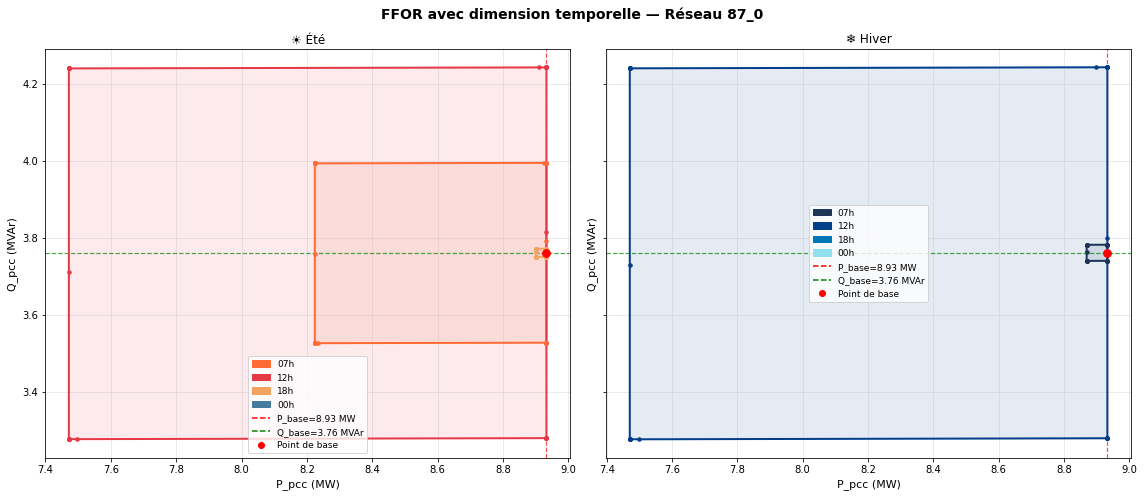

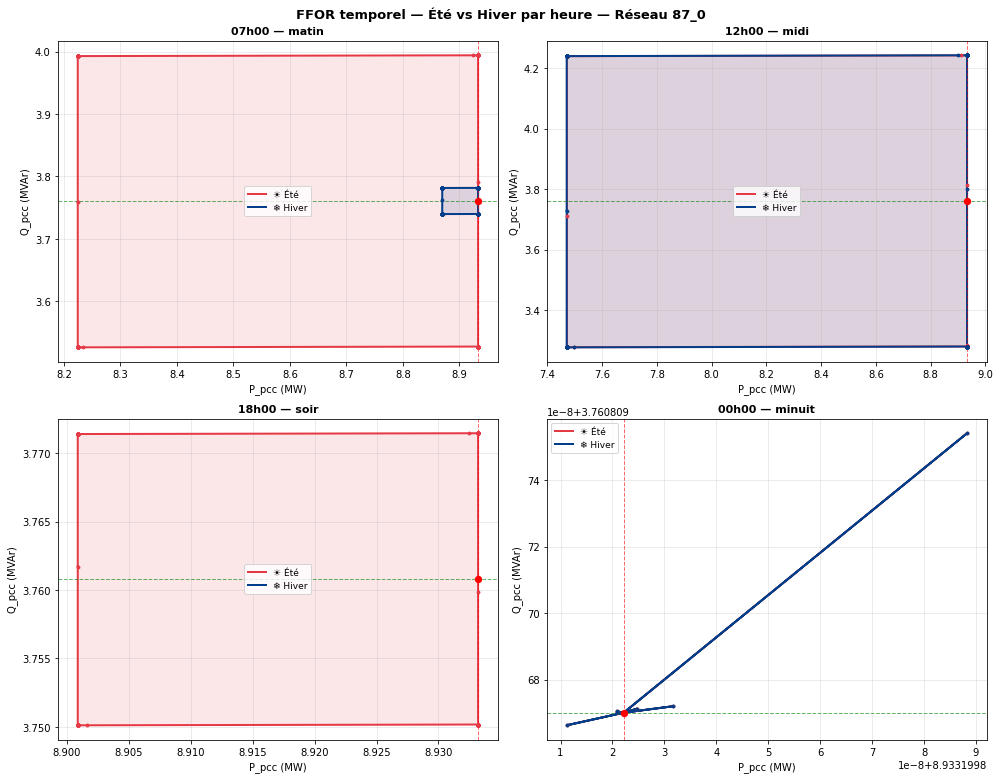

📊 Figures sauvegardées dans output/


In [27]:
# ── Couleurs par heure ────────────────────────────────────────────────────────
COLORS_ETE   = {7: "#FF6B35", 12: "#E63946", 18: "#F4A261", 0: "#457B9D"}
COLORS_HIVER = {7: "#1D3557", 12: "#023E8A", 18: "#0077B6", 0: "#90E0EF"}
HEURE_LABELS = {7: "07h", 12: "12h", 18: "18h", 0: "00h"}

# ── Figure 1 : un panel par saison, 4 heures superposées ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
fig.suptitle("FFOR avec dimension temporelle — Réseau 87_0", fontsize=14, fontweight="bold")

for saison, ax in zip(["Été", "Hiver"], axes):
    colors  = COLORS_ETE if saison == "Été" else COLORS_HIVER
    handles = []
    emoji   = "☀️" if saison == "Été" else "❄️"

    for heure in HEURES:
        if (saison, heure) not in results:
            continue
        P_pts, Q_pts = results[(saison, heure)]
        c = colors[heure]
        ax.plot(P_pts, Q_pts, color=c, linewidth=2, zorder=3)
        ax.fill(P_pts, Q_pts, alpha=0.10, color=c)
        ax.scatter(P_pts[:-1], Q_pts[:-1], s=12, color=c, zorder=4)
        handles.append(mpatches.Patch(color=c, label=HEURE_LABELS[heure]))

    ax.axvline(float(P_base), color="red",   linestyle="--", linewidth=1.2, alpha=0.7)
    ax.axhline(float(Q_base), color="green", linestyle="--", linewidth=1.2, alpha=0.7)
    ax.scatter([float(P_base)], [float(Q_base)], color="red", s=60, zorder=5)
    handles += [
        plt.Line2D([0],[0], color="red",   linestyle="--", label=f"P_base={float(P_base):.2f} MW"),
        plt.Line2D([0],[0], color="green", linestyle="--", label=f"Q_base={float(Q_base):.2f} MVAr"),
        plt.Line2D([0],[0], marker="o", color="red", linestyle="None", label="Point de base"),
    ]

    ax.set_title(f"{emoji} {saison}", fontsize=12)
    ax.set_xlabel("P_pcc (MW)", fontsize=11)
    ax.set_ylabel("Q_pcc (MVAr)", fontsize=11)
    ax.legend(handles=handles, fontsize=9, loc="best")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / "FFOR_temporal_saisons.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 2 : un panel par heure, été vs hiver superposés ───────────────────
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 11))
fig2.suptitle("FFOR temporel — Été vs Hiver par heure — Réseau 87_0", fontsize=13, fontweight="bold")

HEURE_FULL = {7: "07h00 — matin", 12: "12h00 — midi", 18: "18h00 — soir", 0: "00h00 — minuit"}

for ax, heure in zip(axes2.flat, HEURES):
    for saison, color in [("Été", "#E63946"), ("Hiver", "#023E8A")]:
        if (saison, heure) not in results:
            continue
        P_pts, Q_pts = results[(saison, heure)]
        emoji = "☀️" if saison == "Été" else "❄️"
        ax.plot(P_pts, Q_pts, color=color, linewidth=2, label=f"{emoji} {saison}")
        ax.fill(P_pts, Q_pts, alpha=0.12, color=color)
        ax.scatter(P_pts[:-1], Q_pts[:-1], s=8, color=color, zorder=4)

    ax.axvline(float(P_base), color="red",   linestyle="--", linewidth=1, alpha=0.6)
    ax.axhline(float(Q_base), color="green", linestyle="--", linewidth=1, alpha=0.6)
    ax.scatter([float(P_base)], [float(Q_base)], color="red", s=40, zorder=5)
    ax.set_title(HEURE_FULL[heure], fontsize=11, fontweight="bold")
    ax.set_xlabel("P_pcc (MW)")
    ax.set_ylabel("Q_pcc (MVAr)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / "FFOR_temporal_heures.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"📊 Figures sauvegardées dans output/")

In [29]:
# Estimation du temps
import time

# Test sur 1 snapshot
snap_test = snapshots[("Été", 12)]
start = time.time()
solve_ffor_snapshot(1.0, 0.0, snap_test)
t_one = time.time() - start

t_total_h = t_one * 8760 * 72 / 3600
print(f"Temps par optimisation : {t_one:.3f} s")
print(f"Temps total estimé     : {t_total_h:.1f} heures")

Temps par optimisation : 0.701 s
Temps total estimé     : 122.9 heures
